In [1]:
import torch
import numpy as np
import cv2
from ultralytics import YOLO
import segmentation_models_pytorch as smp

In [2]:
deeplab_model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,  # ⚠️ ВАЖНО
    in_channels=3,
    classes=3
)

In [3]:
# YOLO (instance)
yolo_model = YOLO(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\instance_segmentation\yolo\medium\best.pt")

# DeepLab (semantic)
deeplab_model.load_state_dict(torch.load(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\semantic_segmentation\deeplab_30\2\deeplab_lars_30.pth"))
deeplab_model = deeplab_model.cuda()
deeplab_model.eval()

C:\Users\follo\AppData\Local\Temp\ipykernel_26620\1285642035.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  deeplab_model.load_state_dict(torch.load(r"E:\Education\4 co

DeepLabV3Plus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [4]:
PANOPTIC_COLORS = {
    0: (0, 0, 255),      # water
    1: (135, 0, 235),  # sky
    2: (0, 255, 0),      # obstacle

    11: (255, 0, 0),     # ship
    12: (255, 255, 0),   # buoy
    13: (255, 0, 255),   # swimmer
    14: (0, 255, 255),   # animal
    15: (100, 0, 0),     # ship
    16: (255, 100, 0),   # buoy
    17: (255, 0, 100),   # swimmer
    18: (100, 255, 255),
}

In [5]:
YOLO_TO_PANOPTIC = {
    0: 11,  # ship
    1: 12,  # buoy
    2: 13,  # swimmer
    3: 14,  # animal
    4: 15,  # ship
    5: 16,  # buoy
    6: 17,  # swimmer
    7: 18, 
}

In [6]:
def panoptic_fusion(image_bgr):
    h, w = image_bgr.shape[:2]

    img_dl = cv2.resize(image_bgr, (640, 640))
    img_dl = cv2.cvtColor(img_dl, cv2.COLOR_BGR2RGB)
    img_dl = img_dl.astype(np.float32) / 255.0

    img_tensor = torch.from_numpy(img_dl).permute(2,0,1).unsqueeze(0).cuda()

    with torch.no_grad():
        sem_pred = deeplab_model(img_tensor)
        sem_pred = torch.argmax(sem_pred, dim=1).squeeze().cpu().numpy()

    sem_pred = cv2.resize(sem_pred, (w, h), interpolation=cv2.INTER_NEAREST)
    yolo_results = yolo_model(image_bgr, imgsz=640, conf=0.3)[0]

    panoptic_map = sem_pred.copy()

    if yolo_results.masks is not None:
        masks = yolo_results.masks.data.cpu().numpy()
        classes = yolo_results.boxes.cls.cpu().numpy().astype(int)

        for i in range(len(masks)):
            mask = masks[i]
            cls = classes[i]

            mask = cv2.resize(mask, (w, h))
            mask = mask > 0.5

            panoptic_class = YOLO_TO_PANOPTIC.get(cls, 2)

            panoptic_map[mask] = panoptic_class

    return panoptic_map

In [7]:
def visualize_panoptic(image, panoptic_map):
    color_mask = np.zeros_like(image)

    for cls, color in PANOPTIC_COLORS.items():
        color_mask[panoptic_map == cls] = color

    overlay = 0.6 * image + 0.4 * color_mask
    overlay = overlay.astype(np.uint8)

    return overlay


0: 512x640 2 boats, 78.5ms
Speed: 2.3ms preprocess, 78.5ms inference, 3.8ms postprocess per image at shape (1, 3, 512, 640)


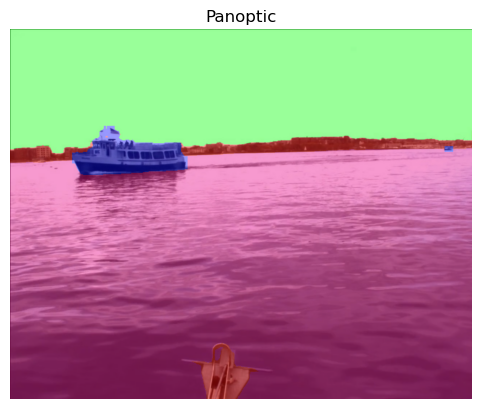

In [10]:
import matplotlib.pyplot as plt

img = cv2.imread(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\data\LaRS_fusion\val\mit_seq_02_01619.jpg")

panoptic = panoptic_fusion(img)
result = visualize_panoptic(img, panoptic)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Panoptic")
plt.axis("off")
plt.show()